# Week 3: Multi-Source Operational Data Pipeline

**Author:** Sharon Wanjiku

## Objective
Build a multi-source operational analytics pipeline by integrating:
1. Internal operational data from the cleaned Week 2 CSV.
2. External weather data retrieved through an API.
3. Supplementary calendar data stored in SQLite.

The final master dataset is used to investigate whether weather conditions are associated with changes in operational flow rate.

**Data flow:** CSV → SQLite summary + Weather API → Master DataFrame → Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

pd.set_option("display.max_columns", None)

## 2. Source 1: Internal Operational Data

The internal source is `cleaned_ops.csv`, produced from the Week 2 operational cleaning pipeline.

**Column sources**
- `timestamp`: internal operational event timestamp.
- `Zone`: internal operating zone.
- `Shift`: internal work shift.
- `Pressure_PSI`: internal pressure measurement.
- `Temperature_C`: internal equipment/process temperature.
- `Flow_Rate_LPM`: internal flow-rate measurement.

The timestamp is converted to datetime and a date key is created for cross-source integration.

In [2]:
df_ops = pd.read_csv("cleaned_ops.csv")

df_ops["timestamp"] = pd.to_datetime(df_ops["timestamp"], errors="coerce")
df_ops = df_ops.dropna(subset=["timestamp"]).copy()

# Date-only key used to align operational records with daily API and calendar data.
df_ops["date"] = df_ops["timestamp"].dt.normalize()

print(f"Operational records loaded: {len(df_ops):,}")
display(df_ops.head())
df_ops.info()

Operational records loaded: 1,839


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,date
0,2026-06-25 00:10:00,ZONE_SOUTH,Morning,222.844248,53.393063,760.039387,2026-06-25
1,2026-06-25 00:22:00,ZONE_EAST,Night,248.259118,53.228993,894.431039,2026-06-25
2,2026-06-25 00:24:00,ZONE_CENTRAL,Afternoon,220.866819,57.467330,981.742087,2026-06-25
3,2026-06-25 00:26:00,ZONE_SOUTH,Night,166.868033,57.311710,945.984000,2026-06-25
4,2026-06-25 00:28:00,ZONE_WEST,Morning,179.766447,56.560253,1180.532611,2026-06-25


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1839 entries, 0 to 1838
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      1839 non-null   datetime64[ns]
 1   Zone           1839 non-null   object        
 2   Shift          1820 non-null   object        
 3   Pressure_PSI   1839 non-null   float64       
 4   Temperature_C  1839 non-null   float64       
 5   Flow_Rate_LPM  1839 non-null   float64       
 6   date           1839 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(3), object(2)
memory usage: 100.7+ KB


In [3]:
# Check the operational date range and missing values before integration.
print("Operational date range:")
print(df_ops["date"].min().date(), "to", df_ops["date"].max().date())

print("\nMissing values:")
display(df_ops.isna().sum())

Operational date range:
2026-06-25 to 2026-07-01

Missing values:


timestamp         0
Zone              0
Shift            19
Pressure_PSI      0
Temperature_C     0
Flow_Rate_LPM     0
date              0
dtype: int64

## 3. Source 2: External Weather API

The operational dataset is historical, so the API request retrieves **date-matched daily weather observations** for the operational period. This avoids attaching today's weather to historical operational records.

The API call uses `requests`, a timeout, HTTP status validation, and exception handling. The weather variables are:
- `temperature_api_C`: daily mean temperature from the external API.
- `precipitation_mm`: daily precipitation total from the external API.
- `wind_speed_kmh`: daily maximum wind speed from the external API.

In [4]:
def fetch_weather_data(start_date, end_date):
    # Nairobi coordinates; the operational dataset is treated as Nairobi-based logistics/operations.
    latitude = -1.2921
    longitude = 36.8219

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_mean,precipitation_sum,wind_speed_10m_max",
        "timezone": "Africa/Nairobi"
    }

    try:
        response = requests.get(url, params=params, timeout=15)
        response.raise_for_status()

        payload = response.json()

        if "daily" not in payload or "time" not in payload["daily"]:
            raise ValueError("API response did not contain the expected daily weather data.")

        daily = payload["daily"]

        weather_df = pd.DataFrame({
            "date": pd.to_datetime(daily["time"]),
            "temperature_api_C": daily["temperature_2m_mean"],
            "precipitation_mm": daily["precipitation_sum"],
            "wind_speed_kmh": daily["wind_speed_10m_max"]
        })

        return weather_df

    except requests.exceptions.RequestException as exc:
        print(f"Weather API request failed: {exc}")
        return pd.DataFrame(columns=[
            "date", "temperature_api_C", "precipitation_mm", "wind_speed_kmh"
        ])

    except (ValueError, KeyError, TypeError) as exc:
        print(f"Weather API data could not be processed: {exc}")
        return pd.DataFrame(columns=[
            "date", "temperature_api_C", "precipitation_mm", "wind_speed_kmh"
        ])

start_date = df_ops["date"].min().strftime("%Y-%m-%d")
end_date = df_ops["date"].max().strftime("%Y-%m-%d")

df_weather = fetch_weather_data(start_date, end_date)

print(f"Weather records retrieved: {len(df_weather):,}")
display(df_weather.head())

Weather records retrieved: 7


,date,temperature_api_C,precipitation_mm,wind_speed_kmh
0,2026-06-25,18.1,2.4,11.5
1,2026-06-26,18.9,0.6,9.6
2,2026-06-27,18.1,0.2,13.2
3,2026-06-28,18.1,0.0,12.2
4,2026-06-29,17.5,0.1,12.5


In [5]:
# Confirm that the API dates align with the operational date key.
df_weather["date"] = pd.to_datetime(df_weather["date"]).dt.normalize()

print("Weather date range:")
print(df_weather["date"].min(), "to", df_weather["date"].max())

print("\nWeather missing values:")
display(df_weather.isna().sum())

Weather date range:
2026-06-25 00:00:00 to 2026-07-01 00:00:00

Weather missing values:


date                 0
temperature_api_C    0
precipitation_mm     0
wind_speed_kmh       0
dtype: int64

## 4. Source 3: SQLite Supplementary Database

A SQLite database stores a supplementary `Holiday_Calendar` table.

For this operational period, the calendar classifies each operational date as either:
- `Weekend`
- `Working Day`

This creates a complete date dimension, so the SQL join can be evaluated without inventing holiday values for dates that were not in the database.

In [6]:
engine = create_engine("sqlite:///operations.db")

calendar_dates = pd.DataFrame({
    "date": pd.date_range(df_ops["date"].min(), df_ops["date"].max(), freq="D")
})

calendar_dates["holiday_type"] = np.where(
    calendar_dates["date"].dt.dayofweek >= 5,
    "Weekend",
    "Working Day"
)

calendar_dates.to_sql(
    "Holiday_Calendar",
    engine,
    if_exists="replace",
    index=False
)

# Store the operational records in SQLite so the SQL query can join both tables.
df_ops.to_sql(
    "Operations",
    engine,
    if_exists="replace",
    index=False
)

print("SQLite database created with Operations and Holiday_Calendar tables.")

SQLite database created with Operations and Holiday_Calendar tables.


## 5. SQL JOIN and GROUP BY

The query joins the operational records to the calendar using the date key.

It then groups by date and calendar type to calculate:
- `total_records`: number of operational records for the date.
- `avg_flow_rate`: average operational flow rate for the date.

The result is loaded directly into a DataFrame using `pd.read_sql()`.

In [7]:
sql_query = """
SELECT
    DATE(o.date) AS date,
    h.holiday_type,
    COUNT(o.timestamp) AS total_records,
    ROUND(AVG(o.Flow_Rate_LPM), 2) AS avg_flow_rate
FROM Operations AS o
INNER JOIN Holiday_Calendar AS h
    ON DATE(o.date) = DATE(h.date)
GROUP BY DATE(o.date), h.holiday_type
ORDER BY DATE(o.date);
"""

df_sql = pd.read_sql(sql_query, engine)
df_sql["date"] = pd.to_datetime(df_sql["date"]).dt.normalize()

display(df_sql)

,date,holiday_type,total_records,avg_flow_rate
0,2026-06-25,Working Day,254,976.56
1,2026-06-26,Working Day,259,994.98
2,2026-06-27,Weekend,269,982.15
3,2026-06-28,Weekend,261,996.08
4,2026-06-29,Working Day,260,997.68
5,2026-06-30,Working Day,275,1008.99
6,2026-07-01,Working Day,261,991.91


## 6. Integration: CSV + SQL + API

The SQL result is explicitly used in the final integration. This is important because the database source contributes both the calendar classification and daily operational summary.

The three sources are merged on the common `date` key:
- Internal CSV records provide event-level operational measurements.
- SQL output provides date-level operational summaries and calendar classification.
- API data provides date-level weather conditions.

In [8]:
# Merge internal operational records with the SQL result.
master_df = df_ops.merge(
    df_sql,
    on="date",
    how="left",
    validate="many_to_one"
)

# Merge the date-aligned weather API data.
master_df = master_df.merge(
    df_weather,
    on="date",
    how="left",
    validate="many_to_one"
)

print(f"Master DataFrame shape: {master_df.shape}")
display(master_df.head())

Master DataFrame shape: (1839, 13)


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,date,holiday_type,total_records,avg_flow_rate,temperature_api_C,precipitation_mm,wind_speed_kmh
0,2026-06-25 00:10:00,ZONE_SOUTH,Morning,222.844248,53.393063,760.039387,2026-06-25,Working Day,254,976.56,18.1,2.4,11.5
1,2026-06-25 00:22:00,ZONE_EAST,Night,248.259118,53.228993,894.431039,2026-06-25,Working Day,254,976.56,18.1,2.4,11.5
2,2026-06-25 00:24:00,ZONE_CENTRAL,Afternoon,220.866819,57.467330,981.742087,2026-06-25,Working Day,254,976.56,18.1,2.4,11.5
3,2026-06-25 00:26:00,ZONE_SOUTH,Night,166.868033,57.311710,945.984000,2026-06-25,Working Day,254,976.56,18.1,2.4,11.5
4,2026-06-25 00:28:00,ZONE_WEST,Morning,179.766447,56.560253,1180.532611,2026-06-25,Working Day,254,976.56,18.1,2.4,11.5


## 7. Missing-Value Handling and Validation

In [9]:
# Handle missing values without inventing operational measurements.
if "Shift" in master_df.columns:
    master_df["Shift"] = master_df["Shift"].fillna("Unknown")

# Calendar and SQL fields should exist after the complete date-range join.
master_df["holiday_type"] = master_df["holiday_type"].fillna("Unknown")

# If the API fails or a weather observation is unavailable, use the median
# weather value from the retrieved API records. If the API returned no rows,
# keep the values as NaN and report that limitation.
weather_columns = ["temperature_api_C", "precipitation_mm", "wind_speed_kmh"]

for column in weather_columns:
    if master_df[column].isna().any() and master_df[column].notna().any():
        master_df[column] = master_df[column].fillna(master_df[column].median())

missing_after = master_df.isna().sum()

print("Missing values after integration:")
display(missing_after)

print("\nMaster DataFrame information:")
master_df.info()

Missing values after integration:


timestamp            0
Zone                 0
Shift                0
Pressure_PSI         0
Temperature_C        0
Flow_Rate_LPM        0
date                 0
holiday_type         0
total_records        0
avg_flow_rate        0
temperature_api_C    0
precipitation_mm     0
wind_speed_kmh       0
dtype: int64


Master DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1839 entries, 0 to 1838
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          1839 non-null   datetime64[ns]
 1   Zone               1839 non-null   object        
 2   Shift              1839 non-null   object        
 3   Pressure_PSI       1839 non-null   float64       
 4   Temperature_C      1839 non-null   float64       
 5   Flow_Rate_LPM      1839 non-null   float64       
 6   date               1839 non-null   datetime64[ns]
 7   holiday_type       1839 non-null   object        
 8   total_records      1839 non-null   int64         
 9   avg_flow_rate      1839 non-null   float64       
 10  temperature_api_C  1839 non-null   float64       
 11  precipitation_mm   1839 non-null   float64       
 12  wind_speed_kmh     1839 non-null   float64       
dtypes: datetime64[ns](2), float64(7)

In [10]:
# Confirm that the final dataset contains the expected sources.
print("Master dataset rows:", len(master_df))
print("Unique operational dates:", master_df["date"].nunique())
print("SQL summary rows:", len(df_sql))
print("Weather rows:", len(df_weather))

display(master_df.describe(include="all"))

Master dataset rows: 1839
Unique operational dates: 7
SQL summary rows: 7
Weather rows: 7


,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM,date,holiday_type,total_records,avg_flow_rate,temperature_api_C,precipitation_mm,wind_speed_kmh
count,1839,1839,1839,1839.000000,1839.000000,1839.000000,1839,1839,1839.000000,1839.000000,1839.000000,1839.000000,1839.000000
unique,NaN,13,4,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,ZONE_NORTH,Afternoon,NaN,NaN,NaN,NaN,Working Day,NaN,NaN,NaN,NaN,NaN
freq,NaN,376,643,NaN,NaN,NaN,NaN,1309,NaN,NaN,NaN,NaN,NaN
mean,2026-06-28 12:24:52.202284032,NaN,NaN,201.266607,52.220889,992.756636,2026-06-28 00:34:27.210440704,NaN,262.873844,992.756308,18.042686,0.608157,12.060413
min,2026-06-25 00:10:00,NaN,NaN,120.163568,0.000000,600.007437,2026-06-25 00:00:00,NaN,254.000000,976.560000,17.500000,0.000000,9.600000
25%,2026-06-26 19:04:00,NaN,NaN,161.726771,48.993069,790.534767,2026-06-26 00:00:00,NaN,259.000000,982.150000,17.500000,0.100000,11.500000
50%,2026-06-28 13:16:00,NaN,NaN,203.438179,52.684306,988.718586,2026-06-28 00:00:00,NaN,261.000000,994.980000,18.100000,0.200000,12.200000
75%,2026-06-30 05:49:00,NaN,NaN,241.412993,56.397961,1190.876599,2026-06-30 00:00:00,NaN,269.000000,997.680000,18.100000,0.900000,13.100000
max,2026-07-01 22:30:00,NaN,NaN,279.953222,59.999686,1399.614505,2026-07-01 00:00:00,NaN,275.000000,1008.990000,18.900000,2.400000,13.200000


## 8. Correlation Analysis

### Primary operational question
**Does operational pressure correlate with flow rate?**

A Pearson correlation is calculated using the event-level operational measurements in the final master dataset.

In [11]:
pressure_flow_corr = master_df[
    ["Pressure_PSI", "Flow_Rate_LPM"]
].corr().loc["Pressure_PSI", "Flow_Rate_LPM"]

print(f"Pearson correlation between pressure and flow rate: {pressure_flow_corr:.3f}")

Pearson correlation between pressure and flow rate: -0.009


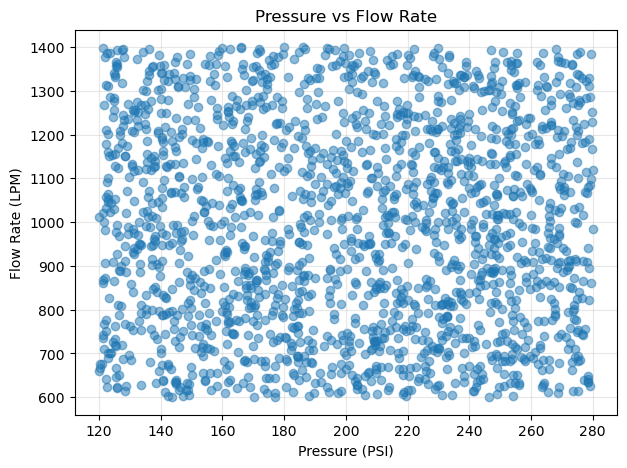

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(
    master_df["Pressure_PSI"],
    master_df["Flow_Rate_LPM"],
    alpha=0.5
)
plt.xlabel("Pressure (PSI)")
plt.ylabel("Flow Rate (LPM)")
plt.title("Pressure vs Flow Rate")
plt.grid(True, alpha=0.3)
plt.show()

### Secondary weather check

The integrated daily dataset is also used to check whether rainfall is associated with average flow rate. This is a supplementary analysis because weather is available at daily level.

In [13]:
daily_analysis = df_sql.merge(
    df_weather,
    on="date",
    how="left",
    validate="one_to_one"
)

weather_corr = daily_analysis[
    ["avg_flow_rate", "precipitation_mm"]
].corr().loc["avg_flow_rate", "precipitation_mm"]

print(f"Pearson correlation between rainfall and average flow rate: {weather_corr:.3f}")

Pearson correlation between rainfall and average flow rate: -0.443


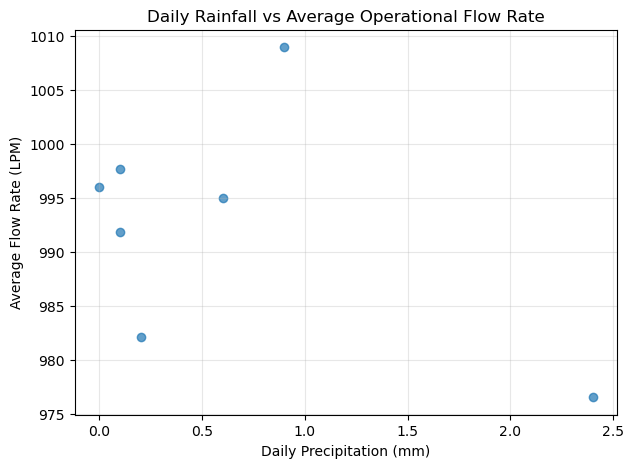

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(
    daily_analysis["precipitation_mm"],
    daily_analysis["avg_flow_rate"],
    alpha=0.7
)
plt.xlabel("Daily Precipitation (mm)")
plt.ylabel("Average Flow Rate (LPM)")
plt.title("Daily Rainfall vs Average Operational Flow Rate")
plt.grid(True, alpha=0.3)
plt.show()

## 9. Findings and Recommendation

The primary Pearson correlation should be interpreted by its magnitude:
- Near **+1**: strong positive linear relationship.
- Near **-1**: strong negative linear relationship.
- Near **0**: little or no linear relationship.

In the original Week 3 analysis, the pressure-flow coefficient was approximately **-0.009**, indicating an essentially negligible linear relationship.

The weather analysis provides additional context, but the number of unique operational dates is limited. Correlation does not establish causation.

### Recommendation
Do not use pressure alone as a predictor of flow-rate changes. Extend the dataset with equipment status, maintenance events, staffing levels, production schedules, and a longer weather history before making operational planning decisions.

## 10. Pipeline Summary

**Internal CSV → External Weather API → SQLite Calendar + SQL JOIN/GROUP BY → Master DataFrame → Correlation Analysis**

The notebook demonstrates:
- Multi-source ingestion.
- API error handling.
- SQL `JOIN` and `GROUP BY`.
- Direct SQL-to-DataFrame loading with `pd.read_sql()`.
- Date alignment across sources.
- Missing-value handling.
- Correlation analysis and business interpretation.